# Notebook 03 - Train PPO trên Azure-derived Multiphase Workload

- Energy Model (mô hình tiêu thụ năng lượng) với DVFS và trạng thái host Active/Sleep/Off.

- DRL Agent dùng PPO để quản lý tài nguyên động.

- VM Consolidation (hợp nhất máy ảo) thông qua `vm_snapshots.csv` và placement/migration trong environment.

- Multi-objective Reward (hàm thưởng đa mục tiêu) cân bằng energy, SLA, latency, migration, nhiệt độ và tuổi thọ phần cứng.

- Evaluation (đánh giá) với baseline RoundRobin, Threshold, BestFit, Fixed-Keep.

- Visualization/Dashboard (trực quan hóa) cho energy, PUE, SLA, DVFS, host state, temperature, migration và energy saving.


*Notebook này dùng `workload_real_multiphase.csv`, tức Azure-derived multiphase workload (workload nhiều pha dẫn xuất từ Azure).*

Ý nghĩa:
- workload này giữ thứ tự timestep và cấu trúc VM snapshot từ Azure;
- cột `demand` được percentile rescaling (tái chuẩn hóa theo phân vị) để có đủ low / medium / high demand;
- dùng để kiểm tra Dynamic Power Management (quản lý nguồn động), DVFS (điều chỉnh điện áp/tần số CPU), Sleep/Off host và SLA.

Không gọi workload này là Azure trace nguyên bản 100% trong báo cáo.


### Bước 1 - Import thư viện và module từ `src/`

In [1]:
from __future__ import annotations

import os
import sys
import json
import re
from pathlib import Path
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv

try:
    import torch
except Exception:
    torch = None


def find_project_root(start: Path | None = None) -> Path:
    # Tìm project root bằng cách đi ngược lên tới thư mục có `src/` và `data/`.
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "src").exists() and (p / "data").exists():
            return p
    # Fallback cho trường hợp notebook nằm trong notebooks/ và user chạy từ đó.
    return Path("..").resolve()


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.energy_env import CloudEnergyEnv, EnvConfig, load_workload_csv
from src.baselines import (
    FixedPolicy,
    RoundRobinPolicy,
    ThresholdPolicy,
    BestFitPolicy,
)
from src.experiment_reporting import (
    evaluate_policies,
    create_experiment_report,
)


print("PROJECT_ROOT =", PROJECT_ROOT)
print("Import từ src/ thành công.")


PROJECT_ROOT = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project
Import từ src/ thành công.


### Bước 2 - Cấu hình experiment và output folder

Mỗi lần chạy sẽ tự tạo một thư mục mới, ví dụ:

```text
> outputs/original/run01_seed42_500000/
> outputs/original/run02_seed40_1000000/
```

hoặc:

```text
> outputs/multiphase/run01_seed42_500000/
> outputs/multiphase/run02_seed40_1000000/
```


In [2]:
EXPERIMENT_KEY = "multiphase"
EXPERIMENT_LABEL = "Experiment B - Azure-derived Multiphase Workload"

WORKLOAD_CSV = PROJECT_ROOT / "data" / "workload_real_multiphase.csv"
VM_SNAPSHOT_CSV = PROJECT_ROOT / "data" / "vm_snapshots.csv"

OUTPUT_BASE_DIR = PROJECT_ROOT / "outputs"
EXPERIMENT_DIR = OUTPUT_BASE_DIR / EXPERIMENT_KEY

# Có thể đổi seed và số timestep trước mỗi lần chạy.
SEED = 42
TOTAL_TIMESTEPS = 1_500_000
N_ENVS = 4
TRAIN_FROM_SCRATCH = True


def get_next_run_dir(experiment_dir: Path, seed: int, timesteps: int) -> tuple[Path, str]:
    experiment_dir.mkdir(parents=True, exist_ok=True)
    pattern = re.compile(r"run(\d+)_seed\d+_\d+$")
    existing_run_numbers = []

    for p in experiment_dir.iterdir():
        if not p.is_dir():
            continue
        match = pattern.match(p.name)
        if match:
            existing_run_numbers.append(int(match.group(1)))

    next_run_number = max(existing_run_numbers) + 1 if existing_run_numbers else 1
    run_name = f"run{next_run_number:02d}_seed{seed}_{timesteps}"
    return experiment_dir / run_name, run_name


RUN_DIR, RUN_NAME = get_next_run_dir(EXPERIMENT_DIR, SEED, TOTAL_TIMESTEPS)

MODEL_DIR = RUN_DIR / "models"
TRACE_DIR = RUN_DIR / "traces"
SUMMARY_DIR = RUN_DIR / "summary"
FIGURE_DIR = RUN_DIR / "figures"
LOG_DIR = RUN_DIR / "logs"
TB_LOG_DIR = LOG_DIR / "tensorboard"

for d in [MODEL_DIR, TRACE_DIR, SUMMARY_DIR, FIGURE_DIR, LOG_DIR, TB_LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / f"ppo_{EXPERIMENT_KEY}_model"
RESULT_CSV = SUMMARY_DIR / "evaluation_results.csv"
SAVING_CSV = SUMMARY_DIR / "energy_saving_percentages.csv"
RUN_CONFIG_PATH = LOG_DIR / "run_config.json"

print("EXPERIMENT_LABEL =", EXPERIMENT_LABEL)
print("WORKLOAD_CSV =", WORKLOAD_CSV)
print("VM_SNAPSHOT_CSV =", VM_SNAPSHOT_CSV)
print("RUN_DIR =", RUN_DIR)
print("MODEL_PATH =", str(MODEL_PATH) + ".zip")

EXPERIMENT_LABEL = Experiment B - Azure-derived Multiphase Workload
WORKLOAD_CSV = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real_multiphase.csv
VM_SNAPSHOT_CSV = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\vm_snapshots.csv
RUN_DIR = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\multiphase\run15_seed42_1500000
MODEL_PATH = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\multiphase\run15_seed42_1500000\models\ppo_multiphase_model.zip


### Bước 3 - Load workload và kiểm tra input

- `demand` là nhu cầu CPU đã chuẩn hóa của workload.
- `phase` nếu có sẽ dùng để phân tích low / medium / high demand.


Số timestep: 2160


,timestep,demand,raw_core_demand,active_vm_count,demand_original,phase,demand_source
0,0,1.1,113390.769344,875495,1.009656,high,azure_derived_percentile_rescaled_multiphase
1,1,1.1,113219.745314,875378,1.008134,high,azure_derived_percentile_rescaled_multiphase
2,2,1.1,112953.144655,874422,1.005760,high,azure_derived_percentile_rescaled_multiphase
3,3,1.1,112844.379743,870308,1.004791,high,azure_derived_percentile_rescaled_multiphase
4,4,1.1,113196.421713,871064,1.007926,high,azure_derived_percentile_rescaled_multiphase


count    2160.000000
mean        0.462697
std         0.269386
min         0.150000
25%         0.257614
50%         0.384897
75%         0.603545
max         1.100000
Name: demand, dtype: float64

,count,min,mean,max
phase,,,,
high,370,0.750899,0.957857,1.100000
low,1141,0.150000,0.262934,0.399790
medium,649,0.400208,0.531602,0.748998


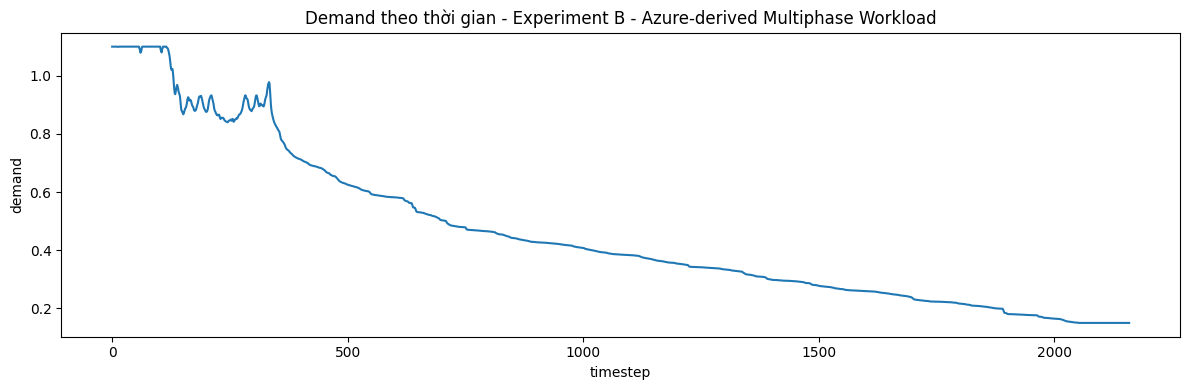

In [3]:
assert WORKLOAD_CSV.exists(), f"Không thấy file workload: {WORKLOAD_CSV}"
assert VM_SNAPSHOT_CSV.exists(), f"Không thấy file vm_snapshots: {VM_SNAPSHOT_CSV}"

workload_df = pd.read_csv(WORKLOAD_CSV)
workload = load_workload_csv(str(WORKLOAD_CSV))

print("Số timestep:", len(workload_df))
display(workload_df.head())
display(workload_df["demand"].describe())

# Nếu workload chưa có phase, tự gán phase để phân tích.
if "phase" not in workload_df.columns:
    workload_df["phase"] = pd.cut(
        workload_df["demand"],
        bins=[0.0, 0.40, 0.75, 2.0],
        labels=["low", "medium", "high"],
        include_lowest=True,
    )

phase_summary = workload_df.groupby("phase", observed=False)["demand"].agg(["count", "min", "mean", "max"])
display(phase_summary)

plt.figure(figsize=(12, 4))
plt.plot(workload_df["timestep"], workload_df["demand"])
plt.title(f"Demand theo thời gian - {EXPERIMENT_LABEL}")
plt.xlabel("timestep")
plt.ylabel("demand")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "input_demand.png", dpi=150)
plt.show()


### Bước 4 - Tạo `EnvConfig` và test environment

`EnvConfig` (cấu hình môi trường) lấy các weight reward mới nhất từ `src.energy_env`. Notebook chỉ override các tham số cần thiết như episode length, seed và đường dẫn `vm_snapshots.csv`.


In [4]:
train_episode_length = 320
# Eval dùng gần toàn bộ workload để so sánh công bằng.
eval_episode_length = len(workload) - 1

reward_overrides = {
    "reward_w_energy": 3.15,

    "reward_w_sla": 4.20,
    "reward_w_latency": 0.14,
    "latency_cap": 3.0,

    "sla_extra_threshold_1": 0.05,
    "sla_extra_penalty_1": 1.00,
    "sla_extra_threshold_2": 0.15,
    "sla_extra_penalty_2": 2.50,
    "sla_penalty_growth_threshold": 0.10,
    "sla_penalty_growth_factor": 5.00,

    "reward_w_dvfs": 1.60,
    "reward_w_dvfs_mismatch": 1.10,

    "reward_w_overprovision": 1.75,
    "reward_w_active_excess": 1.70,
    "reward_w_sleep_excess": 0.25,
    "reward_w_off_bonus": 1.10,

    "reward_w_migration": 0.08,
    "migration_cost": 1.0,
    "reward_w_switch": 0.05,

    "reward_w_temp": 0.18,
    "reward_w_lifetime": 0.07,

    "target_host_util": 0.88,
    "reserve_sleep_hosts": 1,
}

base_config = EnvConfig(
    episode_length=train_episode_length,
    seed=SEED,
    vm_snapshot_path=str(VM_SNAPSHOT_CSV) if VM_SNAPSHOT_CSV.exists() else None,
    **reward_overrides,
)

train_config = base_config
eval_config = replace(base_config, episode_length=eval_episode_length, seed=SEED)

print("train_episode_length =", train_episode_length)
print("eval_episode_length  =", eval_episode_length)
print("vm_snapshot_path     =", train_config.vm_snapshot_path)
print("reward_w_latency    =", train_config.reward_w_latency)
print("latency_cap         =", train_config.latency_cap)
print("reward_w_energy      =", train_config.reward_w_energy)
print("reward_w_sla         =", train_config.reward_w_sla)
print("reward_w_dvfs        =", train_config.reward_w_dvfs)
print("reward_w_dvfs_mismatch =", train_config.reward_w_dvfs_mismatch)
print("reward_w_off_bonus   =", train_config.reward_w_off_bonus)

# Check environment theo chuẩn Gymnasium/SB3.
check_env(CloudEnergyEnv(workload=workload, config=train_config), warn=True)
print("OK: CloudEnergyEnv hợp lệ.")

train_episode_length = 320
eval_episode_length  = 2159
vm_snapshot_path     = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\vm_snapshots.csv
reward_w_latency    = 0.14
latency_cap         = 3.0
reward_w_energy      = 3.15
reward_w_sla         = 4.2
reward_w_dvfs        = 1.6
reward_w_dvfs_mismatch = 1.1
reward_w_off_bonus   = 1.1
OK: CloudEnergyEnv hợp lệ.


### Bước 5 - Chạy thử vài action trước khi train

Mục tiêu là kiểm tra environment có trả về observation (quan sát), reward (phần thưởng), info (thông tin thống kê) ổn không.


In [5]:
env_debug = CloudEnergyEnv(workload=workload, config=train_config)
obs, _ = env_debug.reset(seed=SEED)
print("obs ban đầu shape =", obs.shape)
print("obs ban đầu =", obs)

for action in [0, 4, 2, 5, 1, 3]:
    obs, reward, terminated, truncated, info = env_debug.step(action)
    print(
        f"action={action} reward={reward:.4f} "
        f"demand={info['demand']:.3f} active={info['active_hosts']} "
        f"sleep={info['sleep_hosts']} off={info['off_hosts']} "
        f"dvfs={info['dvfs']:.2f} power={info['power_total']:.2f} sla={info['sla_violation']:.4f}"
    )
    if terminated or truncated:
        break


obs ban đầu shape = (17,)
obs ban đầu = [0.91444314 0.91660947 0.875      0.8333333  0.7344991  0.
 0.13059874 0.03002184 0.125      0.         0.42619577 0.4345219
 0.001      0.         0.01778716 0.00357505 0.        ]
action=0 reward=-2.9430 demand=0.914 active=7 sleep=1 off=0 dvfs=1.00 power=1778.80 sla=0.0000
action=4 reward=-3.6586 demand=0.917 active=7 sleep=1 off=0 dvfs=0.80 power=1538.01 sla=0.1272
action=2 reward=-5.9741 demand=0.917 active=6 sleep=2 off=0 dvfs=0.80 power=1380.59 sla=0.2523
action=5 reward=-5.9375 demand=0.916 active=6 sleep=1 off=1 dvfs=0.80 power=1382.73 sla=0.2510
action=1 reward=-3.6456 demand=0.910 active=7 sleep=0 off=1 dvfs=0.80 power=1573.35 sla=0.1208
action=3 reward=-2.9642 demand=0.903 active=7 sleep=0 off=1 dvfs=1.00 power=1873.64 sla=0.0000


### Bước 6 - Train PPO

PPO (Proximal Policy Optimization – thuật toán học tăng cường sâu) học policy (chính sách hành động) để tối ưu reward đa mục tiêu: energy, SLA, latency, DVFS, migration, temperature, active/sleep/off host.


In [6]:
def make_env(rank: int):
    def _init():
        cfg = replace(train_config, seed=SEED + rank)
        return Monitor(CloudEnergyEnv(workload=workload, config=cfg))
    return _init

policy_kwargs = dict(
    net_arch=dict(pi=[128, 128], vf=[128, 128])
)

device = "cpu"
if torch is not None and torch.cuda.is_available():
    device = "cuda"
print("Using device:", device)

# PPO config ưu tiên học nhanh hơn so với bản debug.
# learning_rate cao hơn giúp 500k timestep có tín hiệu học rõ hơn;
# ent_coef giữ exploration (khám phá hành động) để agent thử DVFS_DOWN / SLEEP / POWER_OFF.
ppo_config = {
    "learning_rate": 2.5e-4,
    "n_steps": 512,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.995,
    "gae_lambda": 0.95,
    "clip_range": 0.20,
    "ent_coef": 0.035,
    "vf_coef": 0.50,
    "max_grad_norm": 0.50,
    "target_kl": 0.025,
}

run_config = {
    "experiment_key": EXPERIMENT_KEY,
    "experiment_label": EXPERIMENT_LABEL,
    "workload_csv": str(WORKLOAD_CSV),
    "vm_snapshot_csv": str(VM_SNAPSHOT_CSV),
    "run_name": RUN_NAME,
    "seed": SEED,
    "total_timesteps": TOTAL_TIMESTEPS,
    "n_envs": N_ENVS,
    "train_episode_length": train_episode_length,
    "eval_episode_length": eval_episode_length,
    "device": device,
    "reward_overrides": reward_overrides,
    "ppo_config": ppo_config,
    "note": "Notebook imports baselines/env/evaluation from src; it does not duplicate baseline algorithms.",
}
RUN_CONFIG_PATH.write_text(json.dumps(run_config, indent=2, ensure_ascii=False), encoding="utf-8")

if TRAIN_FROM_SCRATCH:
    vec_env = DummyVecEnv([make_env(i) for i in range(N_ENVS)])

    model = PPO(
        policy="MlpPolicy",
        env=vec_env,
        policy_kwargs=policy_kwargs,
        verbose=1,
        seed=SEED,
        device=device,
        tensorboard_log=str(TB_LOG_DIR),
        **ppo_config,
    )

    model.learn(total_timesteps=TOTAL_TIMESTEPS)
    model.save(str(MODEL_PATH))
    vec_env.close()
    print("Đã train và lưu model tại:", str(MODEL_PATH) + ".zip")
else:
    model = PPO.load(str(MODEL_PATH) + ".zip", device=device)
    print("Đã load model tại:", str(MODEL_PATH) + ".zip")

Using device: cpu
Using cpu device
Logging to C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\multiphase\run15_seed42_1500000\logs\tensorboard\PPO_1
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 320       |
|    ep_rew_mean     | -1.34e+03 |
| time/              |           |
|    fps             | 223       |
|    iterations      | 1         |
|    time_elapsed    | 9         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 320         |
|    ep_rew_mean          | -1.28e+03   |
| time/                   |             |
|    fps                  | 217         |
|    iterations           | 2           |
|    time_elapsed         | 18          |
|    total_timesteps      | 4096        |
|

### Bước 7 - Evaluate PPO và baseline từ `src.baselines`

Baseline (thuật toán đối chứng) được import từ `src.baselines`, **không code lại trong notebook**.

Các policy được đánh giá:

- `Fixed-Keep`: giữ nguyên action KEEP.
- `RoundRobin`: heuristic kiểu Round Robin ở mức cluster.
- `Threshold`: heuristic theo ngưỡng demand/SLA.
- `BestFit`: heuristic gần với Best Fit.
- `PPO`: agent DRL đã train.

Notebook sẽ lưu thêm các chỉ số quan trọng cho yêu cầu đề tài:

- `avg_sla_violation`: SLA violation trung bình.
- `max_sla_violation`: SLA violation lớn nhất.
- `sla_violation_step_rate`: tỷ lệ timestep bị vi phạm SLA.
- `avg_dvfs`: DVFS trung bình.
- `avg_latency_penalty`: latency penalty trung bình.
- `avg_max_temp`: nhiệt độ lớn nhất trung bình.
- `avg_mean_host_age`: hao mòn/tuổi thọ host trung bình.


In [7]:
loaded_model = PPO.load(str(MODEL_PATH) + ".zip", device="cpu")

policies = [
    ("Fixed-Keep", FixedPolicy(0)),
    ("RoundRobin", RoundRobinPolicy()),
    ("Threshold", ThresholdPolicy()),
    ("BestFit", BestFitPolicy()),
    ("PPO", loaded_model),
]

results_df, trace_dfs = evaluate_policies(
    policies=policies,
    workload=workload,
    config=eval_config,
    trace_dir=TRACE_DIR,
    figure_dir=FIGURE_DIR,
    result_csv=RESULT_CSV,
)

print("Đã lưu kết quả tại:", RESULT_CSV)
display(results_df)


Đã lưu kết quả tại: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\multiphase\run15_seed42_1500000\summary\evaluation_results.csv


,policy,total_reward,total_energy,total_it_energy,avg_power,avg_pue,sla_rate,avg_sla_violation,max_sla_violation,sla_violation_step_rate,...,avg_temp,avg_max_temp,avg_mean_host_age,total_switches,total_migrations,total_migration_cost,avg_migration_cost_per_step,avg_latency_penalty,max_latency_penalty,trace_csv
0,PPO,-3901.679154,2.190685e+06,1.526967e+06,1014.675906,1.437797,0.005298,0.005298,0.121936,0.069940,...,45.199869,62.056670,1222.958292,19,19496,809.142310,0.374776,2.815424,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...
1,BestFit,-6548.142115,2.469397e+06,1.771842e+06,1143.768732,1.395652,0.000000,0.000000,0.000000,0.000000,...,47.378021,61.404586,1403.614092,6,899,127.324854,0.058974,2.075535,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...
2,Threshold,-8938.439504,2.703600e+06,1.987148e+06,1252.246234,1.371958,0.010233,0.010233,0.257271,0.073182,...,48.009329,58.769599,1364.004707,313,42122,848.623224,0.393063,1.579422,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...
3,Fixed-Keep,-10148.677953,2.785601e+06,2.059357e+06,1290.227306,1.338667,0.005175,0.005175,0.090909,0.060213,...,47.865514,56.228048,1372.704884,0,18128,978.396167,0.453171,1.086878,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...
4,RoundRobin,-10406.247002,2.841131e+06,2.100327e+06,1315.947559,1.367579,0.012834,0.012834,0.310198,0.075961,...,47.728461,59.768727,1341.239356,303,43623,979.723935,0.453786,1.413792,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...


### Bước 8 - Tạo summary, biểu đồ và dashboard từ `src.experiment_reporting`

Phần biểu đồ, bảng so sánh, phase analysis và artifact index được gom vào `src/experiment_reporting.py` để notebook ngắn hơn và dễ bảo trì.

C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\src\experiment_reporting.py:230: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(x_min - span * pad_ratio, x_max + span * pad_ratio)


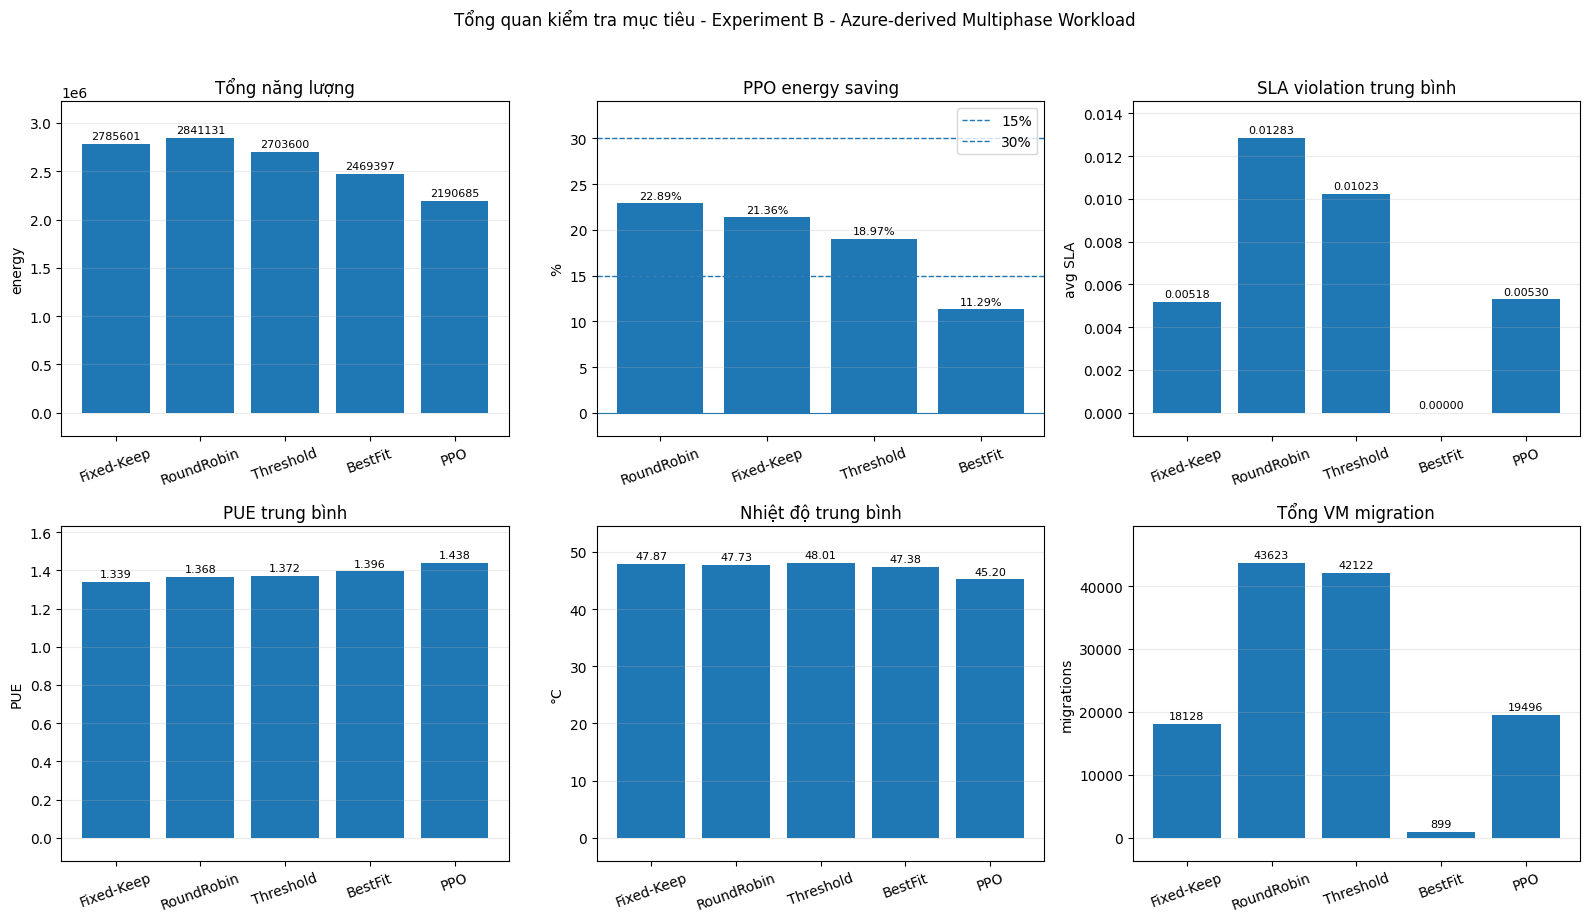

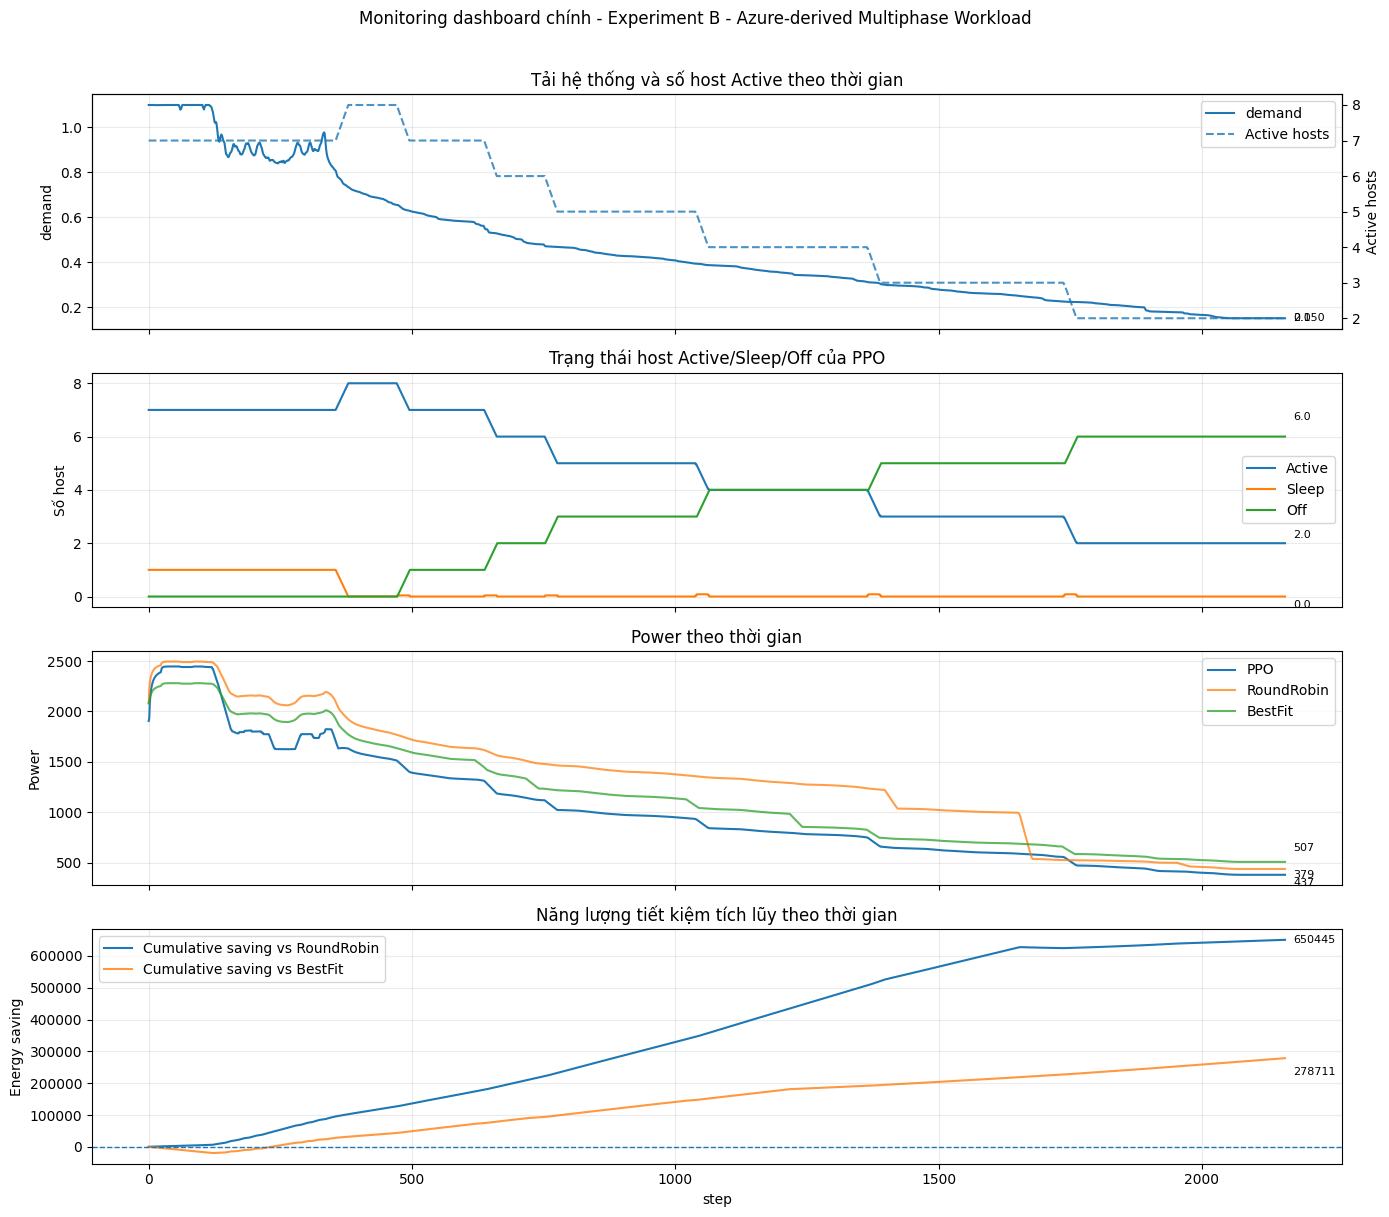

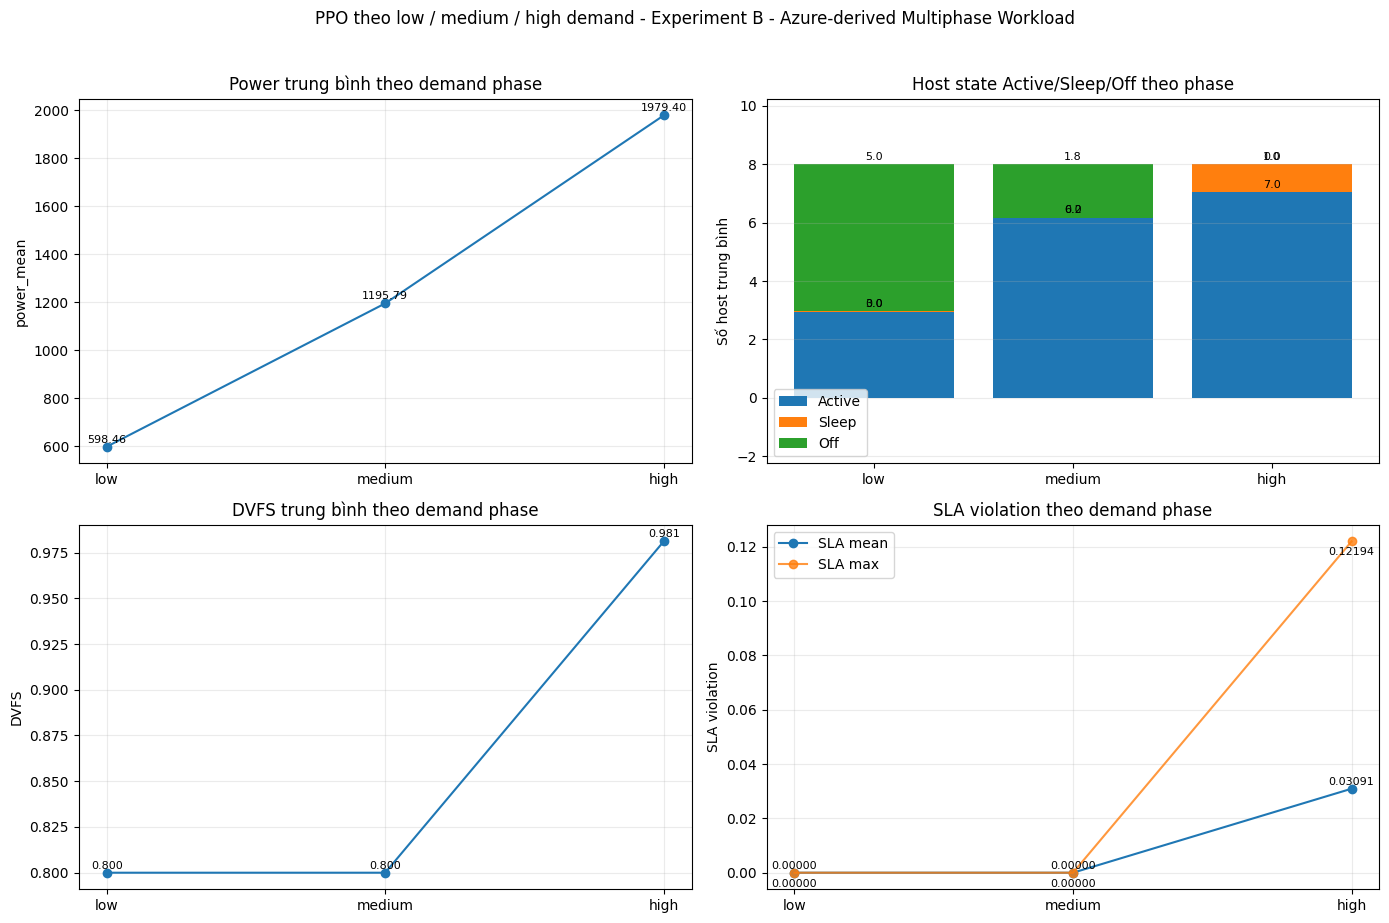

Đã lưu energy saving tại: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\multiphase\run15_seed42_1500000\summary\energy_saving_percentages.csv


,baseline,baseline_energy,ppo_energy,ppo_energy_saving_pct
1,RoundRobin,2.841131e+06,2.190685e+06,22.893895
0,Fixed-Keep,2.785601e+06,2.190685e+06,21.356810
2,Threshold,2.703600e+06,2.190685e+06,18.971535
3,BestFit,2.469397e+06,2.190685e+06,11.286620


Tóm tắt quan hệ demand - active hosts - energy saving theo phase:


,phase,count,demand_mean,active_hosts_mean,sleep_hosts_mean,off_hosts_mean,dvfs_mean,ppo_power_mean,sla_violation_mean,avg_temp_mean,energy_saved_vs_fixed_mean,energy_saved_vs_roundrobin_mean,energy_saved_vs_bestfit_mean
0,low,1140,0.263033,2.954386,0.005263,5.040351,0.800000,598.456121,0.000000,37.344020,424.563021,275.037739,117.485351
1,medium,649,0.531602,6.160247,0.004622,1.835131,0.800000,1195.789054,0.000000,50.193358,183.503633,365.170720,175.868445
2,high,370,0.957857,7.037838,0.962162,0.000000,0.981081,1979.400560,0.030915,60.645526,-22.108725,270.018053,82.809436


Phân tích PPO theo low / medium / high demand:


,phase,count,demand_mean,power_mean,pue_mean,sla_mean,sla_max,active_hosts_mean,sleep_hosts_mean,off_hosts_mean,dvfs_mean,avg_temp_mean,max_temp_mean,latency_penalty_mean,migrations_sum,migration_cost_sum
0,low,1140,0.263033,598.456121,1.448683,0.000000,0.000000,2.954386,0.005263,5.040351,0.800000,37.344020,60.924424,2.741756,365,28.528536
1,medium,649,0.531602,1195.789054,1.406871,0.000000,0.000000,6.160247,0.004622,1.835131,0.800000,50.193358,61.949540,2.839598,172,14.215981
2,high,370,0.957857,1979.400560,1.458501,0.030915,0.121936,7.037838,0.962162,0.000000,0.981081,60.645526,65.733124,3.000000,18959,766.397792


Artifact index:


,category,filename
0,figure,compare_avg_dvfs.png
1,figure,compare_avg_latency_penalty.png
2,figure,compare_avg_mean_host_age.png
3,figure,compare_avg_pue.png
4,figure,compare_avg_sla_violation.png
5,figure,compare_avg_temp.png
6,figure,compare_host_state_stacked.png
7,figure,compare_sla_violation_step_rate.png
8,figure,compare_total_energy.png
9,figure,compare_total_migrations_log.png


RUN_DIR: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\multiphase\run15_seed42_1500000
Số artifact: 34


In [8]:
report_outputs = create_experiment_report(
    results_df=results_df,
    trace_dfs=trace_dfs,
    experiment_label=EXPERIMENT_LABEL,
    summary_dir=SUMMARY_DIR,
    figure_dir=FIGURE_DIR,
    trace_dir=TRACE_DIR,
    saving_csv=SAVING_CSV,
    show_main_figures=True,
)

saving_df = report_outputs["saving_df"]
relationship_by_phase = report_outputs["relationship_by_phase"]
phase_metrics = report_outputs["phase_metrics"]
artifact_index = report_outputs["artifact_index"]

print("Đã lưu energy saving tại:", SAVING_CSV)
display(saving_df)

print("Tóm tắt quan hệ demand - active hosts - energy saving theo phase:")
display(relationship_by_phase)

print("Phân tích PPO theo low / medium / high demand:")
display(phase_metrics)

print("Artifact index:")
display(artifact_index)

print("RUN_DIR:", RUN_DIR)
print("Số artifact:", len(artifact_index))


### Bước 9 - Kết luận nhanh sau khi chạy

Sau khi notebook chạy xong, kiểm tra các file trong:

```text
outputs/multiphase/runXX_seedYY_ZZZZZZ/
```

Trong đó:

- `models/`: model PPO đã train.
- `traces/`: trace từng policy theo timestep.
- `summary/evaluation_results.csv`: bảng kết quả chính.
- `summary/energy_saving_percentages.csv`: PPO tiết kiệm bao nhiêu % so với baseline.
- `summary/ppo_phase_analysis.csv`: phân tích PPO theo low / medium / high demand.
- `summary/demand_active_energy_relationship.csv`: dữ liệu dashboard demand-active-energy saving.
- `summary/artifact_index.csv`: danh sách artifact đã tạo.
- `figures/`: biểu đồ energy, PUE, SLA, DVFS, host states, temperature, migration, dashboard.

Các cột quan trọng để kiểm tra yêu cầu đồ án:

- `total_energy`: tổng năng lượng tiêu thụ.
- `ppo_energy_saving_pct`: tỷ lệ tiết kiệm năng lượng của PPO so với baseline.
- `avg_pue`: PUE trung bình.
- `avg_sla_violation`, `max_sla_violation`, `sla_violation_step_rate`: SLA violation.
- `avg_active_hosts`, `avg_sleep_hosts`, `avg_off_hosts`: trạng thái máy chủ.
- `avg_dvfs`: mức DVFS trung bình.
- `avg_temp`, `avg_max_temp`, `avg_mean_host_age`: nhiệt độ và hao mòn phần cứng.
- `total_migrations`, `total_migration_cost`: VM migration/consolidation.

Nếu kết quả PPO chưa tốt, không vội claim giảm 15–30%. Lúc đó cần xem lại reward, workload, timestep train, action distribution và so sánh từng phase low/medium/high.
